# Modelización Matemática - Tema 2
## Diego Ángel Gallardo Costilla

### Ejercicio 2.12
Empezamos este tema sobre lógica difusa con este primer ejercicio: programar una función triangular y una función trapezoidal.

In [32]:
def triangular(x,a,m,b):
    if x < a or x > b:
        return 0
    if a <= x <= m:
        return (x - a) / (m - a)
    if m < x <= b:
        return (b - x) / (b - m)
    
def trapezoidal(x,a,b,c,d):
    if x <= a or x >= d: 
        return 0
    if b <= x <= c: 
        return 1
    if a < x < b: 
        return (x - a) / (b - a)
    if c < x < d: 
        return (d - x) / (d - c)

### Ejercicio 2.20
Implementamos las operaciones difusas correspondientes:

In [19]:
def minimo(a, b):
    return min(a, b)
def maximo(a, b):
    return max(a, b)
def negacion(a):
    return 1 - a
def mandani(a, b):
    return min(a, b)

### Ejercicio 2.21
El resultado ha sido comprobado en Matlab usando `fuzzyLogicDesigner`. El valor de salida en Variación era -1.21.

### Ejercicio 2.22

A continuación, se introduce el código del controlador difuso, adaptado para el ejemplo del invernadero de esta lección. El resultado es -1.21, tal y como viene dado en los apuntes.

In [34]:
# Primero, hemos de importar las siguientes librerías:
import numpy as np
import matplotlib.pyplot as plt

Fuzzificación: Temp(19.5) -> [('B', 0.1), ('N', 0.75)]
Fuzzificación: Hum(65.0) -> [('A', 0.3333333333333333), ('MA', 0.5)]

Resultado final (Centroide): -1.21


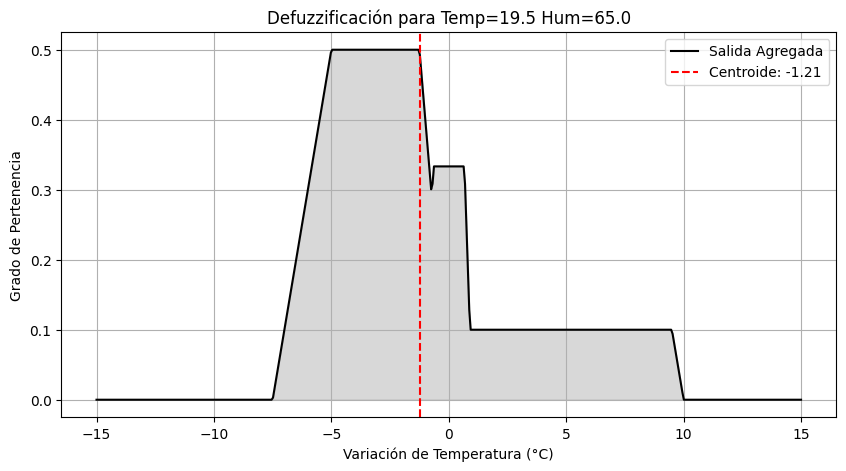

In [ ]:
# 1. FUNCIONES DE PERTENENCIA
# Ya las teníamos definidas en el primer ejercicio, son la triangular y la trapezoidal.

# 2. DEFINICIÓN DE VARIABLES Y ETIQUETAS (Ejemplo Invernadero)
# Rango de temperatura: 0 a 40. Humedad: 0 a 100. Variación: -15 a 15.
temp_labels = {
    'MB': lambda x: trapezoidal(x, 0, 0, 10, 15),
    'B':  lambda x: triangular(x, 10, 15, 20),
    'N':  lambda x: triangular(x, 18, 20, 22),
    'A':  lambda x: triangular(x, 20, 25, 30),
    'MA': lambda x: trapezoidal(x, 25, 30, 40, 40)
}

hum_labels = {
    'A':  lambda x: triangular(x, 40, 55, 70),
    'MA': lambda x: trapezoidal(x, 60, 70, 100, 100)
    # Se pueden añadir MB, B, N siguiendo el mismo patrón
}

output_labels = {
    'BG': lambda x: triangular(x, -15, -10, -7.5),
    'BN': lambda x: triangular(x, -10, -5, -2.5), 
    'BP': lambda x: triangular(x, -7.5, -2.5, 0), 
    'M':  lambda x: triangular(x, -1, 0, 1),       
    'SP': lambda x: triangular(x, 0, 2.5, 7.5),   
    'SN': lambda x: triangular(x, 2.5, 5, 10),     
    'SG': lambda x: triangular(x, 7.5, 10, 15)    
}

# 3. MOTOR DE INFERENCIA
def solve_fuzzy_system(temp_val, hum_val):
    # Fuzzificación (Grados de verdad)
    mu_temp = {k: f(temp_val) for k, f in temp_labels.items()}
    mu_hum = {k: f(hum_val) for k, f in hum_labels.items()}
    
    print(f"Fuzzificación: Temp({temp_val}) -> {[(k,v) for k,v in mu_temp.items() if v>0]}")
    print(f"Fuzzificación: Hum({hum_val}) -> {[(k,v) for k,v in mu_hum.items() if v>0]}")

    # Aplicación de Reglas (Mamdani)
    # Regla 1: IF B AND A THEN SP
    r1 = min(mu_temp['B'], mu_hum['A'])
    # Regla 2: IF B AND MA THEN SN
    r2 = min(mu_temp['B'], mu_hum['MA'])
    # Regla 3: IF N AND A THEN M
    r3 = min(mu_temp['N'], mu_hum['A'])
    # Regla 4: IF N AND MA THEN BP
    r4 = min(mu_temp['N'], mu_hum['MA'])

    # Agregación (Máximo)
    x_range = np.linspace(-15, 15, 500)
    aggregate_membership = []
    
    for x in x_range:
        # Mamdani: min entre el disparo de la regla y la función de salida
        m1 = min(r1, output_labels['SP'](x))
        m2 = min(r2, output_labels['SN'](x))
        m3 = min(r3, output_labels['M'](x))
        m4 = min(r4, output_labels['BP'](x))
        aggregate_membership.append(max(m1, m2, m3, m4))

    # Defuzzificación (Centroide)
    num = np.sum(np.array(aggregate_membership) * x_range)
    den = np.sum(aggregate_membership)
    centroid = num / den if den != 0 else 0
    
    return x_range, aggregate_membership, centroid

# 4. EJECUCIÓN Y VISUALIZACIÓN
t_in, h_in = 19.5, 65.0
x_out, y_out, result = solve_fuzzy_system(t_in, h_in)

print(f"\nResultado final (Centroide): {result:.2f}")

# Gráfico
plt.figure(figsize=(10, 5))
plt.plot(x_out, y_out, 'k-', label='Salida Agregada')
plt.fill_between(x_out, y_out, color='gray', alpha=0.3)
plt.axvline(result, color='r', linestyle='--', label=f'Centroide: {result:.2f}')
plt.title(f"Defuzzificación para Temp={t_in} Hum={h_in}")
plt.xlabel("Variación de Temperatura (°C)")
plt.ylabel("Grado de Pertenencia")
plt.legend()
plt.grid(True)
plt.show()

### Ejercicio 2.29
Sea $T : [0,1] \times [0,1] \rightarrow [0,1]$ una t-norma. Procedamos a demostrar las proposiciones **(1)** y **(2)**.

**(1)** $T(x,0) = 0$, para todo $x \in [0,1]$.

Al ser creciente y estar definida en el intervalo $[0,1]$, como $x\leq 1$, $T(x,0) \leq T(1,0)=0$. Luego al ser $0 \leq T(x,0)$, $T(x,0)=0$.

**(2)** $T(x, y) \leq x$, para todo $x,y \in [0,1]$.

Como $y \le 1$, por la monotonía se tiene que $T(x, y) \le T(x, 1)$ y por la condición de frontera es $T(x, 1) = x$.


Veamos primero para $\leftarrow_{T,n}$
Es creciente en el argumento de la izquierda, $z\leftarrow_{T,n}y$, es decir en z:
Sea $z\leq w$, luego $n(z)\geq n(w)$. Por tanto, $T(y,n(z))\geq T(y,n(w))$, finalmente $n(T(y,n(z)))\leq n(T(y,n(w)))$

### Ejercicio 2.30
Veamos primero que $T_D \leq T$ para cualquier $T$ t-norma.

En caso de que $x, y \in [0, 1)$, entonces $T_{D}(x,y) = 0 \leq T(x,y)$.
Si $x = 1$, $T_D = min(x, y) = y = T(1, y).$ Para $y = 1$ es análogo.

Ahora, veamos que $T \leq T_G$ para cualquier $T$ t-norma.

Dado que por la monotonía $ T(x,y)\leq T(x,1)=x$ y $T(x,y)\leq T(1,y)=y$, será $T(x,y)\leq min\{x,y\}=T_G(x,y)$.

### Ejercicio 2.31

Procederemos a probar que $S_{T,n}: [0,1] \to [0,1]$ es efectivamente una t-conorma.

a) Conmutatividad:

Dado que T es t-norma, $T(n(x),n(y)) = T(n(y),n(x))$ y aplicando la negación se tiene.

b) Suponiendo $ x \leq y $, veamos $n(T(n(x), n(y)))$. Primero, tenemos que $n(y) \leq n(x)$, luego $T(n(x), n(z)) \geq T(n(y), n(z))$, de nuevo por la monotonía de la negación se tiene $S_{T,n}(x,z) = n(T(n(x), n(z))) \leq n(T(n(y), n(z))) = S_{T,n}(y,z)$.

c) $S_{T, n}(x, 0) = n(T(n(x), 0))$, por la condición de frontera de t-norma se tiene $n(T(n(x), 0)) = n(n(x)) = x$

d) Asociatividad:

De nuevo al ser T t-norma, $S_{T,n} (x,S_{T,n}(y,z)) = n(T(n(x),T(n(y),n(z)))) = n(T(T(n(x),n(y)),n(z))) = S_{T,n} (S_{T,n}(x,y),z)$.

### Ejercicio 2.32

Comprobamos la de Gödel: si $y \leq x$:

$S_{T_G,n}(x,y) = 1- min\{1-x,1-y\}= 1-1+x=x$. Análogo si $x \leq y$

Luego, $S_{T_G,n}(x,y) = máx\{x,y\} = S_G$.

La t-conorma producto también:

$S_{T_P,n}(x,y) = 1- (1-x)(1-y)=1-1+y+x-x*y = x+y-x*y$

Veamos qué ocurre con la de Lukasiewicz:

$S_{T_L, n}(x, y) = 1 - max\{1, 2 - x - y\}$

Supongamos que $ 1 < 2 - x - y $, se tiene que $ x + y < 1 $, restando 1, $ x + y < 0 $. Luego $ S_{T_L, n}(x, y) = 1 - 2 + x + y = - 1 + x + y < 0 $, lo que contradice la definición de t-conorma de mandar en $[0, 1]$.



### Ejercicio 2.33

Procederemos a implementarlas, pues. Primero, las t-normas:

In [21]:
def tg(x,y):
    return min(x, y)
def tp(x,y):
    return x*y
def tl(x,y):
    return max(0,x+y-1)

Ahora, las t-conormas:

In [22]:
def sg(x,y):
    return max(x,y)
def sp(x,y):
    return x+y-x*y
def sl(x,y):
    return min(1,x+y)

### Ejercicio 2.38

Primeramente, estudiemos las propiedades del operador $\leftarrow_{T,n}$, definido como $z \leftarrow_{T,n} y = n(T(y, n(z)))$.

- Es creciente en el consecuente, $z \leftarrow_{T,n} y$: Con $z \leq x$, tenemos que $n(z) \geq n(x)$. Por tanto, $T(y, n(z)) \geq T(y, n(x))$, finalmente $n(T(y, n(z))) \leq n(T(y, n(x)))$.

- Es decreciente en el antecedente, $z \leftarrow_{T,n} y$: Con $y \leq w$, por la monotonía de la t-norma tenemos que $T(y, n(z)) \leq T(w, n(z))$. Por tanto, al aplicar la negación, $n(T(y, n(z))) \geq n(T(w, n(z)))$.

Posteriormente, estudiemos las propiedades del operador $\leftarrow_{S,n}$, definido como $z \leftarrow_{S,n} y = S(n(y), z)$.

- Es creciente en el consecuente, $z \leftarrow_{S,n} y$: Con $z \leq x$, por la propiedad de monotonía de la t-conorma, se tiene directamente que $S(n(y), z) \leq S(n(y), x)$.

- Es decreciente en el antecedente, $z \leftarrow_{S,n} y$: Con $y \leq w$, tenemos que $n(y) \geq n(w)$ por la propiedad de la negación. Por tanto, $S(n(y), z) \geq S(n(w), z)$ debido a la monotonía de la t-conorma.

En conclusión, ambos operadores cumplen con las condiciones de la **Definición 2.34** y son, por lo tanto, implicaciones difusas.

### Ejercicio 2.39

Primeramente, comprobemos si el operador $\leftarrow_{T,n}$ cumple la propiedad de adjunción $T(x, y) \leq z \iff x \leq z \leftarrow_{T,n} y$ utilizando la t-norma producto $T(x,y) = x \cdot y$ y la negación básica $n(x) = 1 - x$.

Calculamos el operador $z \leftarrow_{T,n} y$: Aplicando las definiciones, tenemos que $z \leftarrow_{T,n} y = n(T(y, n(z))) = 1 - (y \cdot (1 - z)) = 1 - y + yz$.

Ahora, queremos ver que $x \cdot y \leq z \iff x \leq 1 - y + yz$. Si tomamos los valores $y=0.5$ y $z=0.1$, la condición de la izquierda requiere que $x \cdot 0.5 \leq 0.1$, es decir, $x \leq 0.2$. Por otro lado, la condición de la derecha requiere que $x \leq 1 - 0.5 + (0.5 \cdot 0.1) = 0.55$.

Con $x=0.4$, se cumple que $x \leq 0.55$, pero no se cumple que $x \cdot 0.5 \leq 0.1$ (ya que $0.2 \not\leq 0.1$). Al no satisfacerse la propiedad de adjunción para todos los elementos, el operador $\leftarrow_{T,n}$ no es la implicación residuada de la t-norma producto.

### Ejercicio 2.46

Procedemos a implementar las implicaciones residuadas de las t-normas de Gödel, producto y Lukasiewicz:

In [23]:
def imp_godel(y, z):
    return 1 if y <= z else z
def imp_producto(y, z):
    return 1 if y <= z else z / y
def imp_lukasiewicz(y, z):
    return min(1, 1 - y + z)